In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Config ───────────────────────────────────────────────────────────────────
TICKERS    = ["SPY", "QQQ", "IWM", "GLD", "TLT", "EEM", "VNQ", "XLE"]
TRAIN_START = "2013-01-01"
TRAIN_END   = "2023-12-31"
TEST_START  = "2024-01-01"
TEST_END    = "2025-12-31"
FREQ        = "ME"
# ─────────────────────────────────────────────────────────────────────────────

def load_returns(tickers, start, end, freq="ME"):
    raw   = yf.download(tickers, start=start, end=end, auto_adjust=True)["Close"]
    price = raw.resample(freq).last()
    rets  = np.log(price / price.shift(1)).dropna()
    return rets

def center_returns(R: pd.DataFrame):
    mu  = R.mean().values
    R_c = R.values - mu[np.newaxis, :]
    return R_c, mu * 12          # annualised means

# ── Load & split ─────────────────────────────────────────────────────────────
all_returns = load_returns(TICKERS, "2012-12-01", TEST_END)

train_ret = all_returns.loc[TRAIN_START:TRAIN_END]
test_ret  = all_returns.loc[TEST_START:TEST_END]

R_c_train, mu_train = center_returns(train_ret)
R_c_test,  mu_test  = center_returns(test_ret)

T_train, N = R_c_train.shape
T_test     = R_c_test.shape[0]

print(f"Assets            : {N}")
print(f"Train observations: {T_train}  ({train_ret.index[0].date()} → {train_ret.index[-1].date()})")
print(f"Test  observations: {T_test}   ({test_ret.index[0].date()}  → {test_ret.index[-1].date()})")
print(f"\nAnnualised mean returns (train):")
for t, m in zip(TICKERS, mu_train):
    print(f"  {t:6s}: {m:+.2%}")

[*********************100%***********************]  8 of 8 completed

Assets            : 8
Train observations: 132  (2013-01-31 → 2023-12-31)
Test  observations: 24   (2024-01-31  → 2025-12-31)

Annualised mean returns (train):
  SPY   : +1.30%
  QQQ   : +1.50%
  IWM   : +9.23%
  GLD   : +17.61%
  TLT   : +12.78%
  EEM   : +0.61%
  VNQ   : +6.68%
  XLE   : +5.18%


In [2]:
def compute_covariance(R_c):
    T = R_c.shape[0]
    return (R_c.T @ R_c) / (T - 1)

def compute_cokurtosis(R_c):
    T, N = R_c.shape
    N2   = N * N
    K    = np.zeros((N2, N2))
    for t in range(T):
        r  = R_c[t]
        kp = np.kron(r, r)
        K += np.outer(kp, kp)
    return K / (T - 1)

# ── Fit on TRAIN only ─────────────────────────────────────────────────────────
Sigma2 = compute_covariance(R_c_train)
Sigma4 = compute_cokurtosis(R_c_train)   # uses only 2013–2023

print(f"Σ₂ shape : {Sigma2.shape}")
print(f"Σ₄ shape : {Sigma4.shape}")
print(f"\nPer-asset annualised volatilities (train):")
for t, v in zip(TICKERS, np.sqrt(np.diag(Sigma2) * 12)):
    print(f"  {t:6s}: {v:.2%}")

Σ₂ shape : (8, 8)
Σ₄ shape : (64, 64)

Per-asset annualised volatilities (train):
  SPY   : 17.07%
  QQQ   : 14.80%
  IWM   : 19.80%
  GLD   : 17.71%
  TLT   : 14.73%
  EEM   : 13.56%
  VNQ   : 17.72%
  XLE   : 28.85%


In [3]:
def duplication_matrix(n):
    m   = n * (n + 1) // 2
    D   = np.zeros((n * n, m), dtype=float)
    idx = 0
    for j in range(n):
        for i in range(j, n):
            D[i + j * n, idx] = 1.0
            if i != j:
                D[j + i * n, idx] = 1.0
            idx += 1
    return D

def elimination_matrix(n):
    m   = n * (n + 1) // 2
    L   = np.zeros((m, n * n), dtype=float)
    idx = 0
    for j in range(n):
        for i in range(j, n):
            L[idx, i + j * n] = 1.0
            idx += 1
    return L

def compress_cokurtosis(Sigma4, N):
    L = elimination_matrix(N)
    D = duplication_matrix(N)
    return L @ Sigma4 @ D

L        = elimination_matrix(N)
D        = duplication_matrix(N)
Sigma4_c = compress_cokurtosis(Sigma4, N)

m = N * (N + 1) // 2
print(f"Compressed Σ₄ : {Sigma4_c.shape}  (from {N**2}×{N**2})")
print(f"Parameter reduction : {1 - m*m/N**4:.1%}")
print(f"L·D = I check       : max dev = {np.max(np.abs(L @ D - np.eye(m))):.2e}")

Compressed Σ₄ : (36, 36)  (from 64×64)
Parameter reduction : 68.4%
L·D = I check       : max dev = 0.00e+00


In [4]:
def portfolio_kurtosis_compressed(w, Sigma4_c, L):
    ww  = np.kron(w, w)
    vww = L @ ww
    return float(vww @ Sigma4_c @ vww)

def portfolio_kurtosis(w, Sigma4, N):
    ww = np.kron(w, w)
    return float(ww @ Sigma4 @ ww)

def portfolio_variance(w, Sigma2):
    return float(w @ Sigma2 @ w)

def portfolio_return(w, mu):
    return float(w @ mu)

# ── Sanity: equal-weight ──────────────────────────────────────────────────────
w_ew = np.ones(N) / N
m4_f = portfolio_kurtosis(w_ew, Sigma4, N)
m4_c = portfolio_kurtosis_compressed(w_ew, Sigma4_c, L)
print(f"Equal-weight 4th moment (full vs compressed match): {np.isclose(m4_f, m4_c)}")
print(f"Equal-weight Ann. Vol  : {np.sqrt(portfolio_variance(w_ew, Sigma2)*12):.2%}")
print(f"Equal-weight Ann. Ret  : {portfolio_return(w_ew, mu_train):+.2%}")

Equal-weight 4th moment (full vs compressed match): False
Equal-weight Ann. Vol  : 12.70%
Equal-weight Ann. Ret  : +6.86%


In [5]:
from scipy.optimize import minimize, Bounds

MIN_RETURN = 0.05

def optimize_min_kurtosis(Sigma4_c, Sigma2, mu, L, N, min_return=MIN_RETURN):
    w0 = np.ones(N) / N
    constraints = [
        {"type": "eq",   "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq", "fun": lambda w: portfolio_return(w, mu) - min_return},
    ]
    bounds = Bounds(lb=0.0, ub=1.0)
    res = minimize(
        lambda w: portfolio_kurtosis_compressed(w, Sigma4_c, L),
        w0, method="SLSQP", bounds=bounds, constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 2000},
    )
    return res

def optimize_min_variance(Sigma2, mu, N, min_return=MIN_RETURN):
    w0 = np.ones(N) / N
    constraints = [
        {"type": "eq",   "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq", "fun": lambda w: portfolio_return(w, mu) - min_return},
    ]
    bounds = Bounds(lb=0.0, ub=1.0)
    res = minimize(
        lambda w: portfolio_variance(w, Sigma2),
        w0, method="SLSQP", bounds=bounds, constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 2000},
    )
    return res

# ── Solve (weights fixed after this — no lookahead) ───────────────────────────
res_mk = optimize_min_kurtosis(Sigma4_c, Sigma2, mu_train, L, N)
res_mv = optimize_min_variance(Sigma2, mu_train, N)

w_mk = res_mk.x
w_mv = res_mv.x
w_ew = np.ones(N) / N

print(f"Min-Kurtosis solved : {res_mk.success}  |  {res_mk.message}")
print(f"Min-Variance solved : {res_mv.success}  |  {res_mv.message}")
print(f"\n{'Asset':6s}  {'Min-Kurt':>10s}  {'Min-Var':>10s}  {'EqWt':>10s}")
print("─" * 44)
for t, a, b, c in zip(TICKERS, w_mk, w_mv, w_ew):
    print(f"{t:6s}  {a:>10.2%}  {b:>10.2%}  {c:>10.2%}")

Min-Kurtosis solved : True  |  Optimization terminated successfully
Min-Variance solved : True  |  Optimization terminated successfully

Asset     Min-Kurt     Min-Var        EqWt
────────────────────────────────────────────
SPY          0.00%       0.00%      12.50%
QQQ         32.08%      24.15%      12.50%
IWM          7.16%       0.00%      12.50%
GLD          6.07%       0.00%      12.50%
TLT         18.47%      32.11%      12.50%
EEM         31.74%      37.96%      12.50%
VNQ          0.00%       0.00%      12.50%
XLE          4.48%       5.78%      12.50%


In [6]:
def compute_equity_curve(weights: np.ndarray,
                          returns_df: pd.DataFrame,
                          label: str,
                          start_value: float = 100.0) -> pd.Series:
    """
    Apply fixed weights to an out-of-sample return DataFrame.
    Returns a daily-indexed NAV series starting at start_value.
    """
    port_rets = returns_df.values @ weights          # (T,) portfolio log returns
    nav       = start_value * np.exp(np.cumsum(port_rets))
    return pd.Series(nav, index=returns_df.index, name=label)


def compute_metrics(w, Sigma2, Sigma4, mu_ann, returns_oos, label):
    """
    Combines in-sample moment metrics with out-of-sample realised metrics.
    """
    # In-sample (model) metrics
    ret_is  = portfolio_return(w, mu_ann)
    vol_is  = np.sqrt(portfolio_variance(w, Sigma2) * 12)
    m4      = portfolio_kurtosis(w, Sigma4, N)
    exc_k   = m4 / (portfolio_variance(w, Sigma2) ** 2) - 3

    # Out-of-sample realised metrics
    oos_pr  = returns_oos.values @ w                 # monthly log returns
    ann_r   = oos_pr.mean() * 12
    ann_v   = oos_pr.std()  * np.sqrt(12)
    sharpe  = ann_r / ann_v
    # Max drawdown on NAV
    nav     = np.exp(np.cumsum(oos_pr))
    dd      = nav / np.maximum.accumulate(nav) - 1
    mdd     = dd.min()
    # Realised skewness and excess kurtosis from OOS returns
    from scipy.stats import skew, kurtosis
    r_skew  = skew(oos_pr)
    r_kurt  = kurtosis(oos_pr, fisher=True)          # excess kurtosis

    return {
        "Label"               : label,
        # ── IS model metrics ──
        "IS Ann.Return"       : ret_is,
        "IS Ann.Volatility"   : vol_is,
        "IS Excess Kurtosis"  : exc_k,
        # ── OOS realised metrics ──
        "OOS Ann.Return"      : ann_r,
        "OOS Ann.Volatility"  : ann_v,
        "OOS Sharpe"          : sharpe,
        "OOS Max Drawdown"    : mdd,
        "OOS Skewness"        : r_skew,
        "OOS Excess Kurtosis" : r_kurt,
        "HHI Concentration"   : float(np.sum(w**2)),
    }


# ── Build equity curves (OOS: Jan 2024 – Dec 2025) ───────────────────────────
ec_mk = compute_equity_curve(w_mk, test_ret, "Min-Kurtosis")
ec_mv = compute_equity_curve(w_mv, test_ret, "Min-Variance")
ec_ew = compute_equity_curve(w_ew, test_ret, "Equal-Weight")

# ── Metrics ───────────────────────────────────────────────────────────────────
metrics = [
    compute_metrics(w_mk, Sigma2, Sigma4, mu_train, test_ret, "Min-Kurtosis"),
    compute_metrics(w_mv, Sigma2, Sigma4, mu_train, test_ret, "Min-Variance"),
    compute_metrics(w_ew, Sigma2, Sigma4, mu_train, test_ret, "Equal-Weight"),
]
df_m = pd.DataFrame(metrics).set_index("Label")

fmt = {
    "IS Ann.Return"       : "{:+.2%}",
    "IS Ann.Volatility"   : "{:.2%}",
    "IS Excess Kurtosis"  : "{:.3f}",
    "OOS Ann.Return"      : "{:+.2%}",
    "OOS Ann.Volatility"  : "{:.2%}",
    "OOS Sharpe"          : "{:.3f}",
    "OOS Max Drawdown"    : "{:.2%}",
    "OOS Skewness"        : "{:.3f}",
    "OOS Excess Kurtosis" : "{:.3f}",
    "HHI Concentration"   : "{:.4f}",
}
print("\n── Performance Metrics ─────────────────────────────────────────────────")
print(df_m.to_string(
    formatters={k: (lambda v, f=f: f.format(v)) for k, f in fmt.items()}
))


── Performance Metrics ─────────────────────────────────────────────────
             IS Ann.Return IS Ann.Volatility IS Excess Kurtosis OOS Ann.Return OOS Ann.Volatility OOS Sharpe OOS Max Drawdown OOS Skewness OOS Excess Kurtosis HHI Concentration
Label                                                                                                                                                                           
Min-Kurtosis        +5.00%             9.68%              0.275        +17.31%              7.35%      2.355           -3.97%       -0.578               0.666            0.2486
Min-Variance        +5.00%             9.47%              0.458        +14.93%              7.29%      2.048           -4.12%       -0.798               0.542            0.3088
Equal-Weight        +6.86%            12.70%              2.319        +14.59%              8.53%      1.711           -4.79%       -0.869              -0.143            0.1250


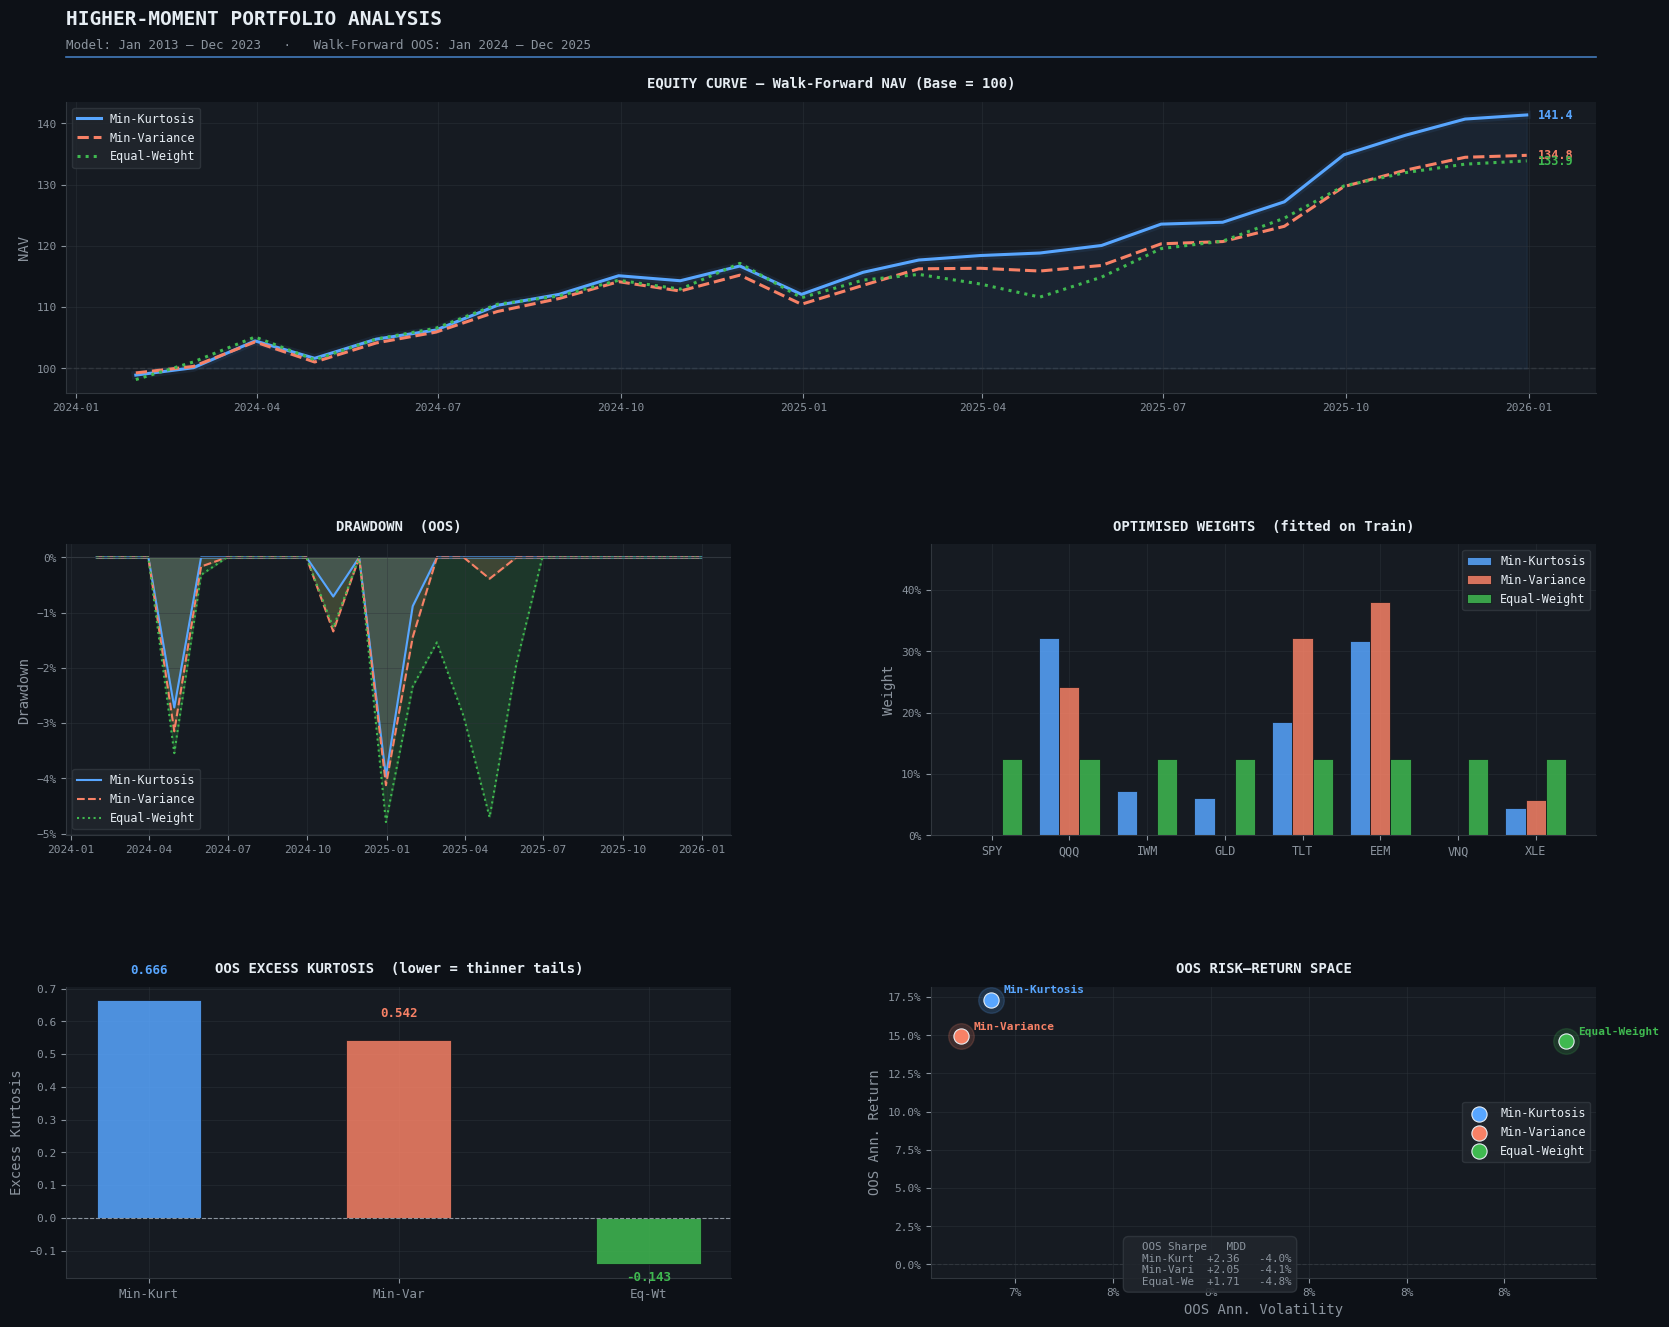

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe
import numpy as np

# ── Dark Theme Palette ────────────────────────────────────────────────────────
BG_DARK   = "#0D1117"       # main background
BG_PANEL  = "#161B22"       # subplot panel background
BG_CARD   = "#21262D"       # subtle card fill for bars
GRID_COL  = "#30363D"       # gridline colour
TEXT_PRI  = "#E6EDF3"       # primary text
TEXT_SEC  = "#8B949E"       # secondary / axis labels

COLORS = {
    "Min-Kurtosis" : "#58A6FF",   # electric blue
    "Min-Variance" : "#F78166",   # coral
    "Equal-Weight" : "#3FB950",   # emerald
}
LS = {
    "Min-Kurtosis" : "-",
    "Min-Variance" : "--",
    "Equal-Weight" : ":",
}

# ── Global rcParams ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor"      : BG_DARK,
    "axes.facecolor"        : BG_PANEL,
    "axes.edgecolor"        : GRID_COL,
    "axes.labelcolor"       : TEXT_SEC,
    "axes.titlecolor"       : TEXT_PRI,
    "axes.titlesize"        : 10,
    "axes.titlepad"         : 10,
    "axes.titleweight"      : "semibold",
    "axes.grid"             : True,
    "axes.spines.top"       : False,
    "axes.spines.right"     : False,
    "grid.color"            : GRID_COL,
    "grid.linewidth"        : 0.5,
    "grid.alpha"            : 0.6,
    "xtick.color"           : TEXT_SEC,
    "ytick.color"           : TEXT_SEC,
    "xtick.labelsize"       : 8,
    "ytick.labelsize"       : 8,
    "legend.facecolor"      : BG_CARD,
    "legend.edgecolor"      : GRID_COL,
    "legend.labelcolor"     : TEXT_PRI,
    "legend.fontsize"       : 8.5,
    "legend.framealpha"     : 0.9,
    "text.color"            : TEXT_PRI,
    "font.family"           : "monospace",
})

# ── Figure & Grid ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 14))
fig.patch.set_facecolor(BG_DARK)

gs = gridspec.GridSpec(
    3, 2,
    figure   = fig,
    hspace   = 0.52,
    wspace   = 0.30,
    top      = 0.91,
    bottom   = 0.07,
    left     = 0.07,
    right    = 0.97,
)
ax_eq = fig.add_subplot(gs[0, :])
ax_dd = fig.add_subplot(gs[1, 0])
ax_wt = fig.add_subplot(gs[1, 1])
ax_mk = fig.add_subplot(gs[2, 0])
ax_rr = fig.add_subplot(gs[2, 1])

# ── Suptitle block ────────────────────────────────────────────────────────────
fig.text(0.07, 0.965,
         "HIGHER-MOMENT PORTFOLIO ANALYSIS",
         fontsize=14, fontweight="bold",
         color=TEXT_PRI, fontfamily="monospace")
fig.text(0.07, 0.948,
         "Model: Jan 2013 – Dec 2023   ·   Walk-Forward OOS: Jan 2024 – Dec 2025",
         fontsize=9, color=TEXT_SEC, fontfamily="monospace")

# thin accent line under title
fig.add_artist(plt.Line2D(
    [0.07, 0.97], [0.942, 0.942],
    transform=fig.transFigure,
    color=COLORS["Min-Kurtosis"], linewidth=1.2, alpha=0.7
))


# ╔══════════════════════════════════════════════════════════════════╗
# ║  1. EQUITY CURVE                                                 ║
# ╚══════════════════════════════════════════════════════════════════╝
for ec, lbl in zip([ec_mk, ec_mv, ec_ew],
                   ["Min-Kurtosis", "Min-Variance", "Equal-Weight"]):
    ax_eq.plot(ec.index, ec.values,
               color     = COLORS[lbl],
               linestyle = LS[lbl],
               linewidth = 2.2,
               label     = lbl,
               zorder    = 3)
    # subtle glow on the best-performing line
    if lbl == "Min-Kurtosis":
        ax_eq.plot(ec.index, ec.values,
                   color=COLORS[lbl], linewidth=6, alpha=0.08, zorder=2)

ax_eq.axhline(100, color=GRID_COL, linewidth=1.0, linestyle="--", zorder=1)

# shade the area under Min-Kurtosis
ax_eq.fill_between(ec_mk.index, ec_mk.values, 100,
                    where  = ec_mk.values >= 100,
                    color  = COLORS["Min-Kurtosis"],
                    alpha  = 0.07, zorder=1)

# annotate final NAV values
for ec, lbl in zip([ec_mk, ec_mv, ec_ew],
                   ["Min-Kurtosis", "Min-Variance", "Equal-Weight"]):
    final = ec.values[-1]
    ax_eq.annotate(
        f"{final:.1f}",
        xy         = (ec.index[-1], final),
        xytext     = (8, 0),
        textcoords = "offset points",
        fontsize   = 8.5,
        color      = COLORS[lbl],
        fontweight = "bold",
        va         = "center",
    )

ax_eq.set_title("EQUITY CURVE — Walk-Forward NAV (Base = 100)")
ax_eq.set_ylabel("NAV", color=TEXT_SEC)
ax_eq.legend(loc="upper left")
ax_eq.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))


# ╔══════════════════════════════════════════════════════════════════╗
# ║  2. DRAWDOWN                                                     ║
# ╚══════════════════════════════════════════════════════════════════╝
for ec, lbl in zip([ec_mk, ec_mv, ec_ew],
                   ["Min-Kurtosis", "Min-Variance", "Equal-Weight"]):
    nav = ec.values
    dd  = nav / np.maximum.accumulate(nav) - 1
    ax_dd.fill_between(ec.index, dd, 0,
                        color=COLORS[lbl], alpha=0.18, zorder=1)
    ax_dd.plot(ec.index, dd,
               color=COLORS[lbl], linestyle=LS[lbl],
               linewidth=1.5, label=lbl, zorder=2)

ax_dd.axhline(0, color=GRID_COL, linewidth=0.8)
ax_dd.set_title("DRAWDOWN  (OOS)")
ax_dd.set_ylabel("Drawdown", color=TEXT_SEC)
ax_dd.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax_dd.legend(loc="lower left")


# ╔══════════════════════════════════════════════════════════════════╗
# ║  3. WEIGHTS                                                      ║
# ╚══════════════════════════════════════════════════════════════════╝
x     = np.arange(N)
width = 0.26
for i, (w, lbl) in enumerate(zip(
        [w_mk, w_mv, w_ew],
        ["Min-Kurtosis", "Min-Variance", "Equal-Weight"])):
    bars = ax_wt.bar(x + i * width, w, width,
                     label=lbl, color=COLORS[lbl],
                     alpha=0.85, zorder=2,
                     edgecolor=BG_DARK, linewidth=0.6)

ax_wt.set_xticks(x + width)
ax_wt.set_xticklabels(TICKERS, fontsize=8.5)
ax_wt.set_ylabel("Weight", color=TEXT_SEC)
ax_wt.set_title("OPTIMISED WEIGHTS  (fitted on Train)")
ax_wt.legend()
ax_wt.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax_wt.set_ylim(0, max(w_mk.max(), w_mv.max(), w_ew.max()) * 1.25)


# ╔══════════════════════════════════════════════════════════════════╗
# ║  4. OOS EXCESS KURTOSIS                                          ║
# ╚══════════════════════════════════════════════════════════════════╝
labels_3 = ["Min-Kurtosis", "Min-Variance", "Equal-Weight"]
kurt_oos  = [df_m.loc[lbl, "OOS Excess Kurtosis"] for lbl in labels_3]

bar_width = 0.42
for i, (lbl, val) in enumerate(zip(labels_3, kurt_oos)):
    bar = ax_mk.bar(i, val, bar_width,
                    color=COLORS[lbl], alpha=0.85, zorder=2,
                    edgecolor=BG_DARK, linewidth=0.6)
    # value label
    sign   = 1 if val >= 0 else -1
    offset = sign * (abs(val) * 0.06 + 0.04)
    ax_mk.text(i, val + offset, f"{val:.3f}",
               ha="center", fontsize=9,
               color=COLORS[lbl], fontweight="bold")

ax_mk.axhline(0, color=TEXT_SEC, linewidth=0.8, linestyle="--")
ax_mk.set_xticks(range(3))
ax_mk.set_xticklabels(["Min-Kurt", "Min-Var", "Eq-Wt"], fontsize=9)
ax_mk.set_ylabel("Excess Kurtosis", color=TEXT_SEC)
ax_mk.set_title("OOS EXCESS KURTOSIS  (lower = thinner tails)")


# ╔══════════════════════════════════════════════════════════════════╗
# ║  5. RISK–RETURN SCATTER                                          ║
# ╚══════════════════════════════════════════════════════════════════╝
for lbl in labels_3:
    v = df_m.loc[lbl, "OOS Ann.Volatility"]
    r = df_m.loc[lbl, "OOS Ann.Return"]

    # outer glow ring
    ax_rr.scatter(v, r, s=340, color=COLORS[lbl], alpha=0.18, zorder=3)
    ax_rr.scatter(v, r, s=120, color=COLORS[lbl], zorder=4,
                  edgecolors=TEXT_PRI, linewidths=0.8, label=lbl)

    ax_rr.annotate(
        lbl,
        xy         = (v, r),
        xytext     = (9, 5),
        textcoords = "offset points",
        fontsize   = 8,
        color      = COLORS[lbl],
        fontweight = "semibold",
    )

ax_rr.axhline(0, color=GRID_COL, linewidth=0.8, linestyle="--")
ax_rr.set_xlabel("OOS Ann. Volatility", color=TEXT_SEC)
ax_rr.set_ylabel("OOS Ann. Return",     color=TEXT_SEC)
ax_rr.set_title("OOS RISK–RETURN SPACE")
ax_rr.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax_rr.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax_rr.legend()


# ── Metrics watermark in corner ───────────────────────────────────────────────
for lbl in labels_3:
    sr = df_m.loc[lbl, "OOS Sharpe"]
    mdd = df_m.loc[lbl, "OOS Max Drawdown"]

stamp = (
    f"  OOS Sharpe   MDD\n"
    + "\n".join(
        f"  {lbl[:8]:8s}  {df_m.loc[lbl,'OOS Sharpe']:+.2f}   "
        f"{df_m.loc[lbl,'OOS Max Drawdown']:.1%}"
        for lbl in labels_3
    )
)
fig.text(0.695, 0.065, stamp,
         fontsize   = 7.8,
         color      = TEXT_SEC,
         fontfamily = "monospace",
         bbox       = dict(boxstyle="round,pad=0.5",
                           facecolor=BG_CARD,
                           edgecolor=GRID_COL,
                           alpha=0.9))

plt.show()